In [1]:
import cooler
import cooltools
from ggner_3d.cm import CLR_CONNS, prepare_view_df, get_expected_cis_df, get_expected_trans_df, get_eig_data
import bbi
import numpy as np
from cooltools import saddle
import seaborn as sns
import matplotlib.pyplot as plt
import multiprocess as mp
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
def plot_saddles(dict_list, control_sample='t0', labels=['trans', 'cis', 'cis_bound']):
    n_samples = len(dict_list[0].keys())
    fig, axs = plt.subplots(len(labels), n_samples, figsize=(20, 5))

    for ax_r, current_saddle_dict in enumerate(dict_list):
        vmin_ = []
        vmax_ = []

        saddle_t0 = current_saddle_dict[control_sample][0] / current_saddle_dict[control_sample][1]

        for i, k in enumerate(current_saddle_dict.keys()):
            if k != control_sample:
                saddle_current = current_saddle_dict[k][0] / current_saddle_dict[k][1]
                l2fc = np.log2(saddle_current / saddle_t0)
                vmin_.append(np.nanmin(l2fc))
                vmax_.append(np.nanmax(l2fc))

        vmin = min(vmin_)
        vmax = max(vmax_)

        for i, k in enumerate(current_saddle_dict.keys()):
            if k == control_sample:
                current_saddle = current_saddle_dict[k][0] / current_saddle_dict[k][1]
                sns.heatmap(
                    current_saddle,
                    ax=axs[ax_r, 0],
                    cmap='vlag',
                    center=1,
                    xticklabels=False,
                    yticklabels=False,
                    square=True
                )
                axs[ax_r, 0].set_title(k)
            else:
                saddle_current = current_saddle_dict[k][0] / current_saddle_dict[k][1]
                l2fc = np.log2(saddle_current / saddle_t0)
                sns.heatmap(
                    l2fc,
                    ax=axs[ax_r, i],
                    cmap='vlag',
                    center=0,
                    xticklabels=False,
                    yticklabels=False,
                    square=True,
                    vmin=vmin,
                    vmax=vmax
                )
                axs[ax_r, i].set_title(f'log2({k}/{control_sample})')

        axs[ax_r, 0].set_ylabel(labels[ax_r], fontsize=12)

    return fig, axs

### pol2 degrons

In [ ]:
resolution = 100_000

sample_names = ['pol2_control', 'pol2_degron']

pol2_control = cooler.Cooler(f'/home/carlos/Clone/ggner-3d/data/degron_pol2/GSM5394172_control_mergeRep_500bp.mcool::/resolutions/{resolution}')
pol2_degron = cooler.Cooler(f'/home/carlos/Clone/ggner-3d/data/degron_pol2/GSM5394173_degron_mergeRep_500bp.mcool::/resolutions/{resolution}')

pol2_clr = {'pol2_control': pol2_control, 'pol2_degron': pol2_degron}

view_df = prepare_view_df(arm=False)

In [ ]:
pol2_cis_expected_ = {
    'pol2_control': cooltools.expected_cis(
            clr=pol2_control,
            nproc=8,
            view_df = view_df,
            clr_weight_name='weight',
        ),
    'pol2_degron': cooltools.expected_cis(
            clr=pol2_degron,
            nproc=8,
            view_df = view_df,
            clr_weight_name='weight',
        )
}

pol2_trans_expected_ = {
    'pol2_control': cooltools.expected_trans(
            clr=pol2_control,
            nproc=8,
            view_df = view_df,
            clr_weight_name='weight',
        ),
    'pol2_degron': cooltools.expected_trans(
            clr=pol2_degron,
            nproc=8,
            view_df = view_df,
            clr_weight_name='weight',
        )
}

In [ ]:
fasta = '/home/carlos/Clone/ggner-3d/hg38.fa'
import bioframe

bins = pol2_control.bins()[:]
hg38_genome = bioframe.load_fasta(fasta)
gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)

_, pol2_ev_track = cooltools.api.eigdecomp.eigs_cis(
    clr=pol2_control,
    phasing_track=gc_cov,
    view_df=view_df,
    n_eigs=3,
    sort_metric='MAD_explained'
)

pol2_ev_track = pol2_ev_track[['chrom', 'start', 'end', 'E1']]

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os

N = 50
Q = (0.025, 0.975)

TRACKS = ['E1']


def process_track(track_name):
    print(f"Processing track: {track_name}")

    track_df = pol2_ev_track.copy()

    trans_saddles_u2os = {}
    for k in sample_names:
        print(f"[{track_name}] Trans - {k}")
        trans_saddles_u2os[k] = saddle(
            clr=pol2_clr[k],
            expected=pol2_trans_expected_[k],
            track=track_df.copy(),
            qrange=Q,
            clr_weight_name='weight',
            n_bins=N,
            contact_type='trans',
            trim_outliers=True,
            expected_value_col='balanced.avg',
        )

    cis_saddles_u2os_full = {}
    for k in sample_names:
        print(f"[{track_name}] Cis - {k}")
        cis_saddles_u2os_full[k] = saddle(
            clr=pol2_clr[k],
            expected=pol2_cis_expected_[k],
            track=track_df.copy(),
            qrange=Q,
            clr_weight_name='weight',
            n_bins=N,
            contact_type='cis',
            max_diag=-1,
            trim_outliers=True,
            expected_value_col='balanced.avg',
        )

    cis_saddles_u2os_upper_bound = {}
    for k in sample_names:
        print(f"[{track_name}] Cis upper bound - {k}")
        cis_saddles_u2os_upper_bound[k] = saddle(
            clr=pol2_clr[k],
            expected=pol2_cis_expected_[k],
            track=track_df.copy(),
            qrange=Q,
            clr_weight_name='weight',
            n_bins=N,
            contact_type='cis',
            max_diag=int(1e7 // resolution),
            trim_outliers=True,
            expected_value_col='balanced.avg',
        )

    fig, axs = plot_saddles(
        [trans_saddles_u2os, cis_saddles_u2os_full, cis_saddles_u2os_upper_bound],
        labels=['trans', 'cis', 'cis_bound'],
        control_sample='pol2_control'
    )

    out_png = f'/home/carlos/Clone/ggner-3d/figs/interactions/pol2_{track_name}_{N}_{resolution}.png'
    out_svg = f'/home/carlos/Clone/ggner-3d/figs/interactions/pol2_{track_name}_{N}_{resolution}.svg'

    fig.savefig(out_png, dpi=300)
    fig.savefig(out_svg)
    plt.close(fig)

    return track_name, out_png, out_svg


max_workers = min(len(TRACKS), os.cpu_count())

with ProcessPoolExecutor(max_workers=max_workers) as ex:
    futures = [ex.submit(process_track, track_name) for track_name in TRACKS]

    for fut in as_completed(futures):
        track_name, out_png, out_svg = fut.result()
        print(f"Done: {track_name}")
        print(out_png)
        print(out_svg)

### wapl degrons

In [ ]:
resolution = 100_000

sample_names = ['wapl_control', 'wapl_degron']

mcool_control='/home/carlos/Clone/ggner-3d/data/degron_wapl/GSE178982_WAPL-UT_pool.mcool'
mcool_degron='/home/carlos/Clone/ggner-3d/data/degron_wapl/GSE178982_WAPL-AID_pool.mcool'

wapl_control = cooler.Cooler(f'{mcool_control}::/resolutions/{resolution}')
wapl_degron = cooler.Cooler(f'{mcool_degron}::/resolutions/{resolution}')

wapl_clr = {'wapl_control': wapl_control, 'wapl_degron': wapl_degron}

view_df = {
    'chrom': wapl_control.chromnames,
    'start': [0] * len(wapl_control.chromnames),
    'end': [wapl_control.chromsizes[chrom] for chrom in wapl_control.chromnames],
    'name': wapl_control.chromnames
}

import pandas as pd
view_df = pd.DataFrame(view_df)
view_df = view_df.loc[~view_df['chrom'].str.contains('chrY|chrM')].reset_index(drop=True)

In [ ]:
wapl_cis_expected_ = {
    'wapl_control': cooltools.expected_cis(
            clr=wapl_control,
            nproc=8,
            view_df = view_df,
            clr_weight_name='weight',
        ),
    'wapl_degron': cooltools.expected_cis(
            clr=wapl_degron,
            nproc=8,
            view_df = view_df,
            clr_weight_name='weight',
        )
}

wapl_trans_expected_ = {
    'wapl_control': cooltools.expected_trans(
            clr=wapl_control,
            nproc=8,
            view_df = view_df,
            clr_weight_name='weight',
        ),
    'wapl_degron': cooltools.expected_trans(
            clr=wapl_degron,
            nproc=8,
            view_df = view_df,
            clr_weight_name='weight',
        )
}

In [ ]:
fasta = '/home/carlos/Clone/ggner-3d/hg38.fa'
import bioframe

bins = wapl_control.bins()[:]
hg38_genome = bioframe.load_fasta(fasta)
gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)

_, wapl_ev_track = cooltools.api.eigdecomp.eigs_cis(
    clr=wapl_control,
    phasing_track=gc_cov,
    view_df=view_df,
    n_eigs=3,
    sort_metric='MAD_explained'
)

wapl_ev_track = wapl_ev_track[['chrom', 'start', 'end', 'E1']]

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os

N = 50
Q = (0.025, 0.975)

TRACKS = ['E1']


def process_track(track_name):
    print(f"Processing track: {track_name}")

    track_df = wapl_ev_track.copy()

    trans_saddles_u2os = {}
    for k in sample_names:
        print(f"[{track_name}] Trans - {k}")
        trans_saddles_u2os[k] = saddle(
            clr=wapl_clr[k],
            expected=wapl_trans_expected_[k],
            track=track_df.copy(),
            qrange=Q,
            clr_weight_name='weight',
            n_bins=N,
            contact_type='trans',
            trim_outliers=True,
            expected_value_col='balanced.avg',
            view_df=view_df
        )

    cis_saddles_u2os_full = {}
    for k in sample_names:
        print(f"[{track_name}] Cis - {k}")
        cis_saddles_u2os_full[k] = saddle(
            clr=wapl_clr[k],
            expected=wapl_cis_expected_[k],
            track=track_df.copy(),
            qrange=Q,
            clr_weight_name='weight',
            n_bins=N,
            contact_type='cis',
            max_diag=-1,
            trim_outliers=True,
            expected_value_col='balanced.avg',
            view_df=view_df
        )

    cis_saddles_u2os_upper_bound = {}
    for k in sample_names:
        print(f"[{track_name}] Cis upper bound - {k}")
        cis_saddles_u2os_upper_bound[k] = saddle(
            clr=wapl_clr[k],
            expected=wapl_cis_expected_[k],
            track=track_df.copy(),
            qrange=Q,
            clr_weight_name='weight',
            n_bins=N,
            contact_type='cis',
            max_diag=int(1e7 // resolution),
            trim_outliers=True,
            expected_value_col='balanced.avg',
            view_df=view_df
        )

    fig, axs = plot_saddles(
        [trans_saddles_u2os, cis_saddles_u2os_full, cis_saddles_u2os_upper_bound],
        labels=['trans', 'cis', 'cis_bound'],
        control_sample='wapl_control'
    )

    out_png = f'/home/carlos/Clone/ggner-3d/figs/interactions/wapl_{track_name}_{N}_{resolution}.png'
    out_svg = f'/home/carlos/Clone/ggner-3d/figs/interactions/wapl_{track_name}_{N}_{resolution}.svg'

    fig.savefig(out_png, dpi=300)
    fig.savefig(out_svg)
    plt.close(fig)

    return track_name, out_png, out_svg


max_workers = min(len(TRACKS), os.cpu_count())

with ProcessPoolExecutor(max_workers=max_workers) as ex:
    futures = [ex.submit(process_track, track_name) for track_name in TRACKS]

    for fut in as_completed(futures):
        track_name, out_png, out_svg = fut.result()
        print(f"Done: {track_name}")
        print(out_png)
        print(out_svg)

### u2os - wt

In [ ]:
resolution = 100_000
clr_ = CLR_CONNS(resolution)

# prepare expected

from cooltools.sandbox import obs_over_exp_cooler

view_df = prepare_view_df(arm=False)

sample_names_u2os = ['WTnoUV', 'WT1h', 'WT3h', 'WT6h']

expected_dict_cis = {k: get_expected_cis_df(k, resolution_kb=resolution//1000, label='chrom') for k in sample_names_u2os}
expected_dict_trans = {k: get_expected_trans_df(k, resolution_kb=resolution // 1000) for k in sample_names_u2os}

In [ ]:
bins_table = clr_['WTnoUV'].bins()[:]


damage_0_bw = '/home/carlos/oldies/ner_collab/damageseq/obs0_rpm.1000bp.bw'
damage_3_bw = '/home/carlos/oldies/ner_collab/damageseq/obs3_rpm.1000bp.bw'

damage_0_stack = bbi.stackup(
    damage_0_bw,
    bins_table.chrom,
    bins_table.start,
    bins_table.end,
    summary='sum',
    bins=1)

damage_3_stack = bbi.stackup(
    damage_3_bw,
    bins_table.chrom,
    bins_table.start,
    bins_table.end,
    summary='sum',
    bins=1)

repair_stack = damage_0_stack.flatten() - damage_3_stack.flatten()

In [ ]:
bins_table_u2os = bins_table[['chrom', 'start', 'end']].copy()
bins_table_u2os['repair'] = repair_stack
bins_table_u2os['0h_damage'] = damage_0_stack.flatten()
bins_table_u2os['3h_damage'] = damage_3_stack.flatten()
bins_table_u2os['WTnoUV_E1'] = get_eig_data('WTnoUV', resolution=resolution)[1]['E1']
bins_table_u2os['XPCnoUV_E1'] = get_eig_data('XPCnoUV', resolution=resolution)[1]['E1']

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os

N = 50
Q = (0.025, 0.975)

TRACKS = ['repair', '0h_damage', '3h_damage', 'WTnoUV_E1', 'XPCnoUV_E1']


def process_track(track_name):
    print(f"Processing track: {track_name}")

    track_df = bins_table_u2os[['chrom', 'start', 'end', track_name]].copy()

    trans_saddles_u2os = {}
    for k in sample_names_u2os:
        print(f"[{track_name}] Trans - {k}")
        trans_saddles_u2os[k] = saddle(
            clr=clr_[k],
            expected=expected_dict_trans[k],
            track=track_df.copy(),
            qrange=Q,
            clr_weight_name='sweight',
            n_bins=N,
            contact_type='trans',
            trim_outliers=True,
            expected_value_col='balanced.avg',
        )

    cis_saddles_u2os_full = {}
    for k in sample_names_u2os:
        print(f"[{track_name}] Cis - {k}")
        cis_saddles_u2os_full[k] = saddle(
            clr=clr_[k],
            expected=expected_dict_cis[k],
            track=track_df.copy(),
            qrange=Q,
            clr_weight_name='sweight',
            n_bins=N,
            contact_type='cis',
            max_diag=-1,
            trim_outliers=True,
            expected_value_col='balanced.avg',
        )

    cis_saddles_u2os_upper_bound = {}
    for k in sample_names_u2os:
        print(f"[{track_name}] Cis upper bound - {k}")
        cis_saddles_u2os_upper_bound[k] = saddle(
            clr=clr_[k],
            expected=expected_dict_cis[k],
            track=track_df.copy(),
            qrange=Q,
            clr_weight_name='sweight',
            n_bins=N,
            contact_type='cis',
            max_diag=int(1e7 // resolution),
            trim_outliers=True,
            expected_value_col='balanced.avg',
        )

    fig, axs = plot_saddles(
        [trans_saddles_u2os, cis_saddles_u2os_full, cis_saddles_u2os_upper_bound],
        labels=['trans', 'cis', 'cis_bound'],
        control_sample='WTnoUV'
    )

    out_png = f'/home/carlos/Clone/ggner-3d/figs/interactions/u2os_{track_name}_{N}_{resolution}.png'
    out_svg = f'/home/carlos/Clone/ggner-3d/figs/interactions/u2os_{track_name}_{N}_{resolution}.svg'

    fig.savefig(out_png, dpi=300)
    fig.savefig(out_svg)
    plt.close(fig)

    return track_name, out_png, out_svg


max_workers = min(len(TRACKS), os.cpu_count())

with ProcessPoolExecutor(max_workers=max_workers) as ex:
    futures = [ex.submit(process_track, track_name) for track_name in TRACKS]

    for fut in as_completed(futures):
        track_name, out_png, out_svg = fut.result()
        print(f"Done: {track_name}")
        print(out_png)
        print(out_svg)

### u2os - xpc

In [ ]:
resolution = 100_000
clr_ = CLR_CONNS(resolution)

# prepare expected

from cooltools.sandbox import obs_over_exp_cooler

view_df = prepare_view_df(arm=False)

sample_names_u2os = ['XPCnoUV', 'XPC3h', 'WTnoUV']

expected_dict_cis = {k: get_expected_cis_df(k, resolution_kb=resolution//1000, label='chrom') for k in sample_names_u2os}
expected_dict_trans = {k: get_expected_trans_df(k, resolution_kb=resolution // 1000) for k in sample_names_u2os}

In [ ]:
bins_table = clr_['WTnoUV'].bins()[:]

In [ ]:
bins_table_u2os = bins_table[['chrom', 'start', 'end']].copy()
bins_table_u2os['XPCnoUV_E1'] = get_eig_data('XPCnoUV', resolution=resolution)[1]['E1']

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os

N = 50
Q = (0.025, 0.975)

TRACKS = ['XPCnoUV_E1']

def process_track(track_name):
    print(f"Processing track: {track_name}")

    track_df = bins_table_u2os[['chrom', 'start', 'end', track_name]].copy()

    trans_saddles_u2os = {}
    for k in sample_names_u2os:
        print(f"[{track_name}] Trans - {k}")
        trans_saddles_u2os[k] = saddle(
            clr=clr_[k],
            expected=expected_dict_trans[k],
            track=track_df.copy(),
            qrange=Q,
            clr_weight_name='sweight',
            n_bins=N,
            contact_type='trans',
            trim_outliers=True,
            expected_value_col='balanced.avg',
        )

    cis_saddles_u2os_full = {}
    for k in sample_names_u2os:
        print(f"[{track_name}] Cis - {k}")
        cis_saddles_u2os_full[k] = saddle(
            clr=clr_[k],
            expected=expected_dict_cis[k],
            track=track_df.copy(),
            qrange=Q,
            clr_weight_name='sweight',
            n_bins=N,
            contact_type='cis',
            max_diag=-1,
            trim_outliers=True,
            expected_value_col='balanced.avg',
        )

    cis_saddles_u2os_upper_bound = {}
    for k in sample_names_u2os:
        print(f"[{track_name}] Cis upper bound - {k}")
        cis_saddles_u2os_upper_bound[k] = saddle(
            clr=clr_[k],
            expected=expected_dict_cis[k],
            track=track_df.copy(),
            qrange=Q,
            clr_weight_name='sweight',
            n_bins=N,
            contact_type='cis',
            max_diag=int(1e7 // resolution),
            trim_outliers=True,
            expected_value_col='balanced.avg',
        )

    fig, axs = plot_saddles(
        [trans_saddles_u2os, cis_saddles_u2os_full, cis_saddles_u2os_upper_bound],
        labels=['trans', 'cis', 'cis_bound'],
        control_sample='XPCnoUV'
    )

    out_png = f'/home/carlos/Clone/ggner-3d/figs/interactions/u2os_{track_name}_{N}_{resolution}.png'
    out_svg = f'/home/carlos/Clone/ggner-3d/figs/interactions/u2os_{track_name}_{N}_{resolution}.svg'

    fig.savefig(out_png, dpi=300)
    fig.savefig(out_svg)
    plt.close(fig)

    return track_name, out_png, out_svg


max_workers = min(len(TRACKS), os.cpu_count())

with ProcessPoolExecutor(max_workers=max_workers) as ex:
    futures = [ex.submit(process_track, track_name) for track_name in TRACKS]

    for fut in as_completed(futures):
        track_name, out_png, out_svg = fut.result()
        print(f"Done: {track_name}")
        print(out_png)
        print(out_svg)

### HeLa prep

In [ ]:
resolution = 100_000
clr_t0 = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289939_t0_q30.mcool::/resolutions/{resolution}")
clr_t12 = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289940_t12_q30.mcool::/resolutions/{resolution}")
clr_t30 = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289941_t30_q30.mcool::/resolutions/{resolution}")
clr_t60 = cooler.Cooler(f"/home/carlos/Clone/ggner-3d/data/hela/GSM8289942_t60_q30.mcool::/resolutions/{resolution}")
clr_hela_ = {
    't0': clr_t0,
    't12': clr_t12,
    't30': clr_t30,
    't60': clr_t60,
}

In [ ]:
fasta = '/home/carlos/Clone/ggner-3d/hg38.fa'
import bioframe

bins = clr_t0.bins()[:]
hg38_genome = bioframe.load_fasta(fasta)
gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)

In [ ]:
pool = mp.Pool(4)

view_df = prepare_view_df(arm=False)

eigvals, eigvec_table = cooltools.eigs_cis(
            clr=clr_hela_['t0'],
            phasing_track=gc_cov,
            view_df=view_df,
            n_eigs=3,
            clr_weight_name='full',
            sort_metric='MAD_explained',
            map=pool.map
        )

In [ ]:
ev1_t0 = eigvec_table['E1'].values

In [ ]:
view_df = prepare_view_df(arm=False)

In [ ]:
cis_weight = 'weight'
trans_weight = 'full'

hela_expected_cis_dict = {k: cooltools.expected_cis(
            clr=clr_hela_[k],
            nproc=10,
            view_df = view_df,
            clr_weight_name=cis_weight,
        ) for k in clr_hela_.keys()}

hela_expected_trans_dict = {k: cooltools.expected_trans(
            clr=clr_hela_[k],
            nproc=10,
            view_df=view_df,
            clr_weight_name=trans_weight,
        ) for k, v in clr_hela_.items()}

In [ ]:
hela_expected_cis_dict = {
    k: df.loc[df.region1 == df.region2].reset_index(drop=True) for k, df in hela_expected_cis_dict.items()
}

hela_expected_trans_dict = {
    k: df.loc[df.region1 != df.region2].reset_index(drop=True) for k, df in hela_expected_trans_dict.items()
}

In [ ]:
# prepare rnaseq track

bins_table_hela = clr_hela_['t0'].bins()[:]

rna_bw_dict = {
    't0': ['/home/carlos/oldies/manuscripts/notebooks/viz/merged_t00.bw'],
    't12': ['/home/carlos/oldies/manuscripts/notebooks/viz/merged_t12.bw'],
    't30': ['/home/carlos/oldies/manuscripts/notebooks/viz/merged_t30.bw'],
    't60': ['/home/carlos/oldies/manuscripts/notebooks/viz/merged_t60.bw']
}

pol2_dict = {
    'hela_nouv_pol2': ['/home/carlos/Downloads/ENCFF144IVU.bigWig']
}

xr_seq_dict = {
    'CPD_real_over_sim': ['/home/carlos/oldies/manuscripts/notebooks/bws/XR_CPD_real_over_sim_res1000.bw'],
    '64PP_real_over_sim': ['/home/carlos/oldies/manuscripts/notebooks/bws/XR_64_real_over_sim_res1000.bw']
}

t0_rna_stack = bbi.stackup(
    rna_bw_dict['t0'][0],
    bins_table_hela.chrom,
    bins_table_hela.start,
    bins_table_hela.end,
    summary='sum',
    bins=1)

t12_rna_stack = bbi.stackup(
    rna_bw_dict['t12'][0],
    bins_table_hela.chrom,
    bins_table_hela.start,
    bins_table_hela.end,
    summary='sum',
    bins=1)

pol2_stack = bbi.stackup(
    pol2_dict['hela_nouv_pol2'][0],
    bins_table_hela.chrom,
    bins_table_hela.start,
    bins_table_hela.end,
    summary='sum',
    bins=1)

xr_cpd_stack = bbi.stackup(
    xr_seq_dict['CPD_real_over_sim'][0],
    bins_table_hela.chrom,
    bins_table_hela.start,
    bins_table_hela.end,
    summary='sum',
    bins=1)

xr_64pp_stack = bbi.stackup(
    xr_seq_dict['64PP_real_over_sim'][0],
    bins_table_hela.chrom,
    bins_table_hela.start,
    bins_table_hela.end,
    summary='sum',
    bins=1)

In [ ]:
rna_diff = t12_rna_stack.flatten() - t0_rna_stack.flatten()
bins_table_hela = bins_table_hela[['chrom', 'start', 'end']].copy()
bins_table_hela['rna_diff'] = rna_diff * -1 
bins_table_hela['t0_rna'] = t0_rna_stack.flatten()
bins_table_hela['pol2'] = pol2_stack.flatten()
bins_table_hela['xr_cpd'] = xr_cpd_stack.flatten()
bins_table_hela['xr_64pp'] = xr_64pp_stack.flatten()
bins_table_hela['ev1_t0'] = ev1_t0

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import os

N = 50
Q = (0.025, 0.975)

TRACKS = ['rna_diff', 't0_rna', 'pol2', 'xr_cpd', 'xr_64pp', 'ev1_t0']
sample_names = list(clr_hela_.keys())

def process_track(track_name):
    print(f"Processing track: {track_name}")

    track_df = bins_table_hela[['chrom', 'start', 'end', track_name]].copy()

    trans_saddles = {}
    for k in sample_names:
        print(f"[{track_name}] Trans - {k}")
        trans_saddles[k] = saddle(
            clr=clr_hela_[k],
            expected=hela_expected_trans_dict[k],
            track=track_df.copy(),
            qrange=Q,
            clr_weight_name='full',
            n_bins=N,
            contact_type='trans',
            trim_outliers=True,
            expected_value_col='balanced.avg',
            view_df=view_df
        )

    cis_saddles_full = {}
    for k in sample_names:
        print(f"[{track_name}] Cis - {k}")
        cis_saddles_full[k] = saddle(
            clr=clr_hela_[k],
            expected=hela_expected_cis_dict[k],
            track=track_df.copy(),
            qrange=Q,
            clr_weight_name='weight',
            n_bins=N,
            contact_type='cis',
            max_diag=-1,
            trim_outliers=True,
            expected_value_col='balanced.avg',
            view_df=view_df
        )

    cis_saddles_upper_bound = {}
    for k in sample_names:
        print(f"[{track_name}] Cis upper bound - {k}")
        cis_saddles_upper_bound[k] = saddle(
            clr=clr_hela_[k],
            expected=hela_expected_cis_dict[k],
            track=track_df.copy(),
            qrange=Q,
            clr_weight_name='weight',
            n_bins=N,
            contact_type='cis',
            max_diag=int(1e7 // resolution),
            trim_outliers=True,
            expected_value_col='balanced.avg',
            view_df=view_df
        )

    fig, axs = plot_saddles(
        [trans_saddles, cis_saddles_full, cis_saddles_upper_bound],
        labels=['trans', 'cis', 'cis_bound'],
        control_sample='t0'
    )

    out_png = f'/home/carlos/Clone/ggner-3d/figs/interactions/hela_{track_name}_{N}_{resolution}.png'
    out_svg = f'/home/carlos/Clone/ggner-3d/figs/interactions/hela_{track_name}_{N}_{resolution}.svg'

    fig.savefig(out_png, dpi=300)
    fig.savefig(out_svg)
    plt.close(fig)

    return track_name, out_png, out_svg


max_workers = min(len(TRACKS), os.cpu_count())

with ProcessPoolExecutor(max_workers=max_workers) as ex:
    futures = [ex.submit(process_track, track_name) for track_name in TRACKS]

    for fut in as_completed(futures):
        track_name, out_png, out_svg = fut.result()
        print(f"Done: {track_name}")
        print(out_png)
        print(out_svg)

### arm to arm

In [2]:
from ggner_3d.saddle import pq_saddle, saddle_mp
import cooltools
from ggner_3d.cm import CLR_CONNS, prepare_view_df, get_expected_trans_df, get_eig_data

view_df_arm = prepare_view_df(arm=True)
view_df_chrom = prepare_view_df(arm=False)
resolution = 100_000
clr_ = CLR_CONNS(resolution)
NPROC = 8

sample_names = ['WTnoUV', 'WT1h', 'WT3h', 'WT6h', 'XPCnoUV', 'XPC3h']

cis_expected_ = {k: cooltools.api.expected.expected_cis(
    clr_[k],
    view_df=view_df_arm,
    clr_weight_name='sweight',
    nproc=NPROC,
    intra_only=False
) for k in sample_names}

trans_expected_ = {k: get_expected_trans_df(k, resolution_kb=resolution // 1000) for k in sample_names}

expected_same_arm = {
    k: df.loc[df.region1 == df.region2].reset_index(drop=True) for k, df in cis_expected_.items()
}

expected_p_q = {
    k: df.loc[df.region1 != df.region2].reset_index(drop=True) for k, df in cis_expected_.items()
}

evals, evecs = get_eig_data('WTnoUV', resolution=resolution)
evecs = evecs[['chrom', 'start', 'end', 'E1']]

n_bins = 50
qrange = (0.05, 0.95)

pq_saddles = {
    k: pq_saddle(
    clr=clr_[k],
    expected_pq=expected_p_q[k],
    track=evecs,
    view_df_arm=view_df_arm,
    clr_weight_name="sweight",
    expected_value_col="balanced.avg",
    n_bins=n_bins,
    qrange=qrange,
    trim_outliers=True
)['saddle']

    for k in sample_names
}

trans_saddles = {
    k: saddle_mp(
        clr=clr_[k],
        expected=trans_expected_[k],
        track=evecs,
        view_df=view_df_chrom,
        clr_weight_name="sweight",
        expected_value_col="balanced.avg",
        n_bins=n_bins,
        contact_type='trans',
        qrange=qrange,
        trim_outliers=True,
        nproc=NPROC
    )
    for k in sample_names
}

same_arm_saddles = {
    k: saddle_mp(
        clr=clr_[k],
        expected=expected_same_arm[k],
        track=evecs,
        view_df=view_df_arm,
        clr_weight_name="sweight",
        expected_value_col="balanced.avg",
        n_bins=n_bins,
        contact_type='cis',
        max_diag=-1,
        qrange=qrange,
        trim_outliers=True,
        nproc=NPROC
    )
    for k in sample_names
}

def sc2saddle(saddle_dict):
    new_dict = {k: sd[0] / sd[1] for k, sd in saddle_dict.items()}
    return new_dict

trans_saddles = sc2saddle(trans_saddles)
same_arm_saddles = sc2saddle(same_arm_saddles)

INFO:root:creating a Pool of 8 workers
/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
INFO:root:creating a Pool of 8 workers
/home/carlos/Clone/ggner-3d/.venv/lib/python3.12/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
/home/carlos/Clone/ggner-3d/src/ggner_3d/saddle.py:348: RuntimeWarning: invalid value encountered in divide
  oe = obs / exp_mat
/home/car

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def _to_matrix(x):
    """
    Normalize different saddle outputs to a plain matrix.
    - cooltools.saddle output after sc2saddle: already ndarray
    - cooltools.saddle raw output: (sum, count)
    - pq_saddle output: dict with key 'saddle'
    """
    if isinstance(x, dict):
        return x["saddle"]
    if isinstance(x, tuple) and len(x) == 2:
        s, c = x
        out = s / c
        out[c == 0] = np.nan
        return out
    return x


def _log2_matrix(mtx):
    out = np.full_like(mtx, np.nan, dtype=float)
    valid = np.isfinite(mtx) & (mtx > 0)
    out[valid] = np.log2(mtx[valid])
    return out


def _log2fc_matrix(base, comp):
    out = np.full_like(base, np.nan, dtype=float)
    valid = (
        np.isfinite(base) & np.isfinite(comp) &
        (base > 0) & (comp > 0)
    )
    out[valid] = np.log2(comp[valid] / base[valid])
    return out


def plot_saddle_comparison_3x2(
    comparison,
    trans_saddles,
    pq_saddles,
    same_arm_saddles,
    figsize=(10, 14),
    cmap="vlag",
):
    s0, s1 = comparison

    saddle_sets = [
        ("trans", _to_matrix(trans_saddles[s0]), _to_matrix(trans_saddles[s1])),
        ("pq", _to_matrix(pq_saddles[s0]), _to_matrix(pq_saddles[s1])),
        ("same arm", _to_matrix(same_arm_saddles[s0]), _to_matrix(same_arm_saddles[s1])),
    ]

    fig, axs = plt.subplots(3, 2, figsize=figsize)

    for i, (row_name, m0, m1) in enumerate(saddle_sets):
        m0_log2 = _log2_matrix(m0)
        l2fc = _log2fc_matrix(m0, m1)

        # symmetric color scaling per panel
        vmax0 = np.nanmax(np.abs(m0_log2)) if np.isfinite(m0_log2).any() else 1
        vmax1 = np.nanmax(np.abs(l2fc)) if np.isfinite(l2fc).any() else 1

        sns.heatmap(
            m0_log2,
            ax=axs[i, 0],
            cmap=cmap,
            center=0,
            vmin=-vmax0,
            vmax=vmax0,
            cbar_kws={"label": f"log2 saddle ({s0})"},
            square=True,
        )
        axs[i, 0].set_title(f"{row_name}: {s0}")
        axs[i, 0].set_xlabel("quantile bin")
        axs[i, 0].set_ylabel("quantile bin")

        sns.heatmap(
            l2fc,
            ax=axs[i, 1],
            cmap=cmap,
            center=0,
            vmin=-vmax1,
            vmax=vmax1,
            cbar_kws={"label": f"log2FC ({s1}/{s0})"},
            square=True,
        )
        axs[i, 1].set_title(f"{row_name}: log2({s1} / {s0})")
        axs[i, 1].set_xlabel("quantile bin")
        axs[i, 1].set_ylabel("quantile bin")

    plt.tight_layout()
    plt.show()

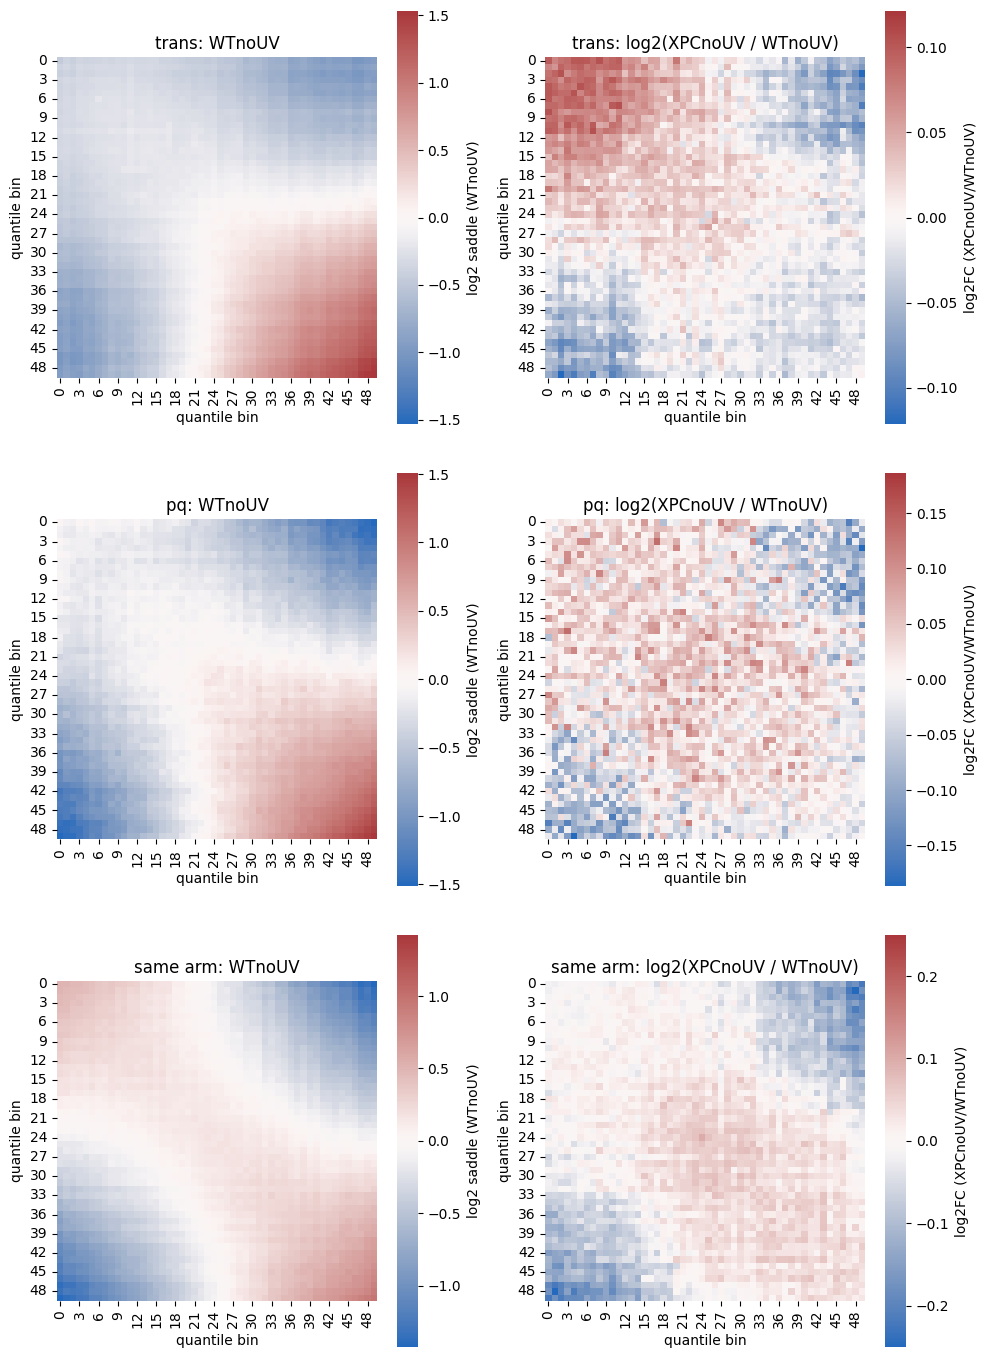

In [5]:
comparison = ('WTnoUV', 'XPCnoUV')

plot_saddle_comparison_3x2(
    comparison=comparison,
    trans_saddles=trans_saddles,
    pq_saddles=pq_saddles,
    same_arm_saddles=same_arm_saddles,
)